In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vishnutavanam2709/merfish-staq/merfish.h5ad


In [2]:
!pip install scanpy anndata torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.2 MB/s eta 0:00:00


In [3]:
# stage 1 - preprocessing
# load raw data, remove blank probes, save raw counts,
# log transform, run PCA

import os
import scanpy as sc
import scipy.sparse as sp
import warnings
warnings.filterwarnings("ignore")

RAW_DATA  = "/kaggle/input/datasets/vishnutavanam2709/merfish-staq/merfish.h5ad"
SAVE_DIR  = "/kaggle/working"

print("--- Stage 1: Preprocessing ---")

adata = sc.read_h5ad(RAW_DATA)
print(f"loaded: {adata.n_obs} cells x {adata.n_vars} genes")

# remove blank probes (noise, not real genes)
blank_mask = adata.var_names.str.startswith("Blank")
adata = adata[:, ~blank_mask].copy()
print(f"after removing blanks: {adata.n_vars} genes")

# save raw counts before any transform (needed for decoder later)
if sp.issparse(adata.X):
    adata.X = adata.X.toarray().astype("float32")
adata.layers["counts"] = adata.X.copy()

# log transform
sc.pp.log1p(adata, base=2)
adata.layers["x_hat"] = adata.X.copy()
print("log2(1+x) applied, saved as x_hat")

# PCA
sc.tl.pca(adata, n_comps=30)
print(f"PCA done: {adata.obsm['X_pca'].shape}")

adata.write_h5ad(os.path.join(SAVE_DIR, "stage1.h5ad"))
print("[SUCCESS] saved stage1.h5ad")

--- Stage 1: Preprocessing ---
loaded: 73655 cells x 161 genes
after removing blanks: 156 genes
log2(1+x) applied, saved as x_hat
PCA done: (73655, 30)
[SUCCESS] saved stage1.h5ad


In [4]:
# stage 2 - build two knn graphs
# W_T: cells similar in gene expression (PCA space)
# W_S: cells close in physical space

import os
import numpy as np
import anndata
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

SAVE_DIR = "/kaggle/working"

print("--- Stage 2: kNN Graphs ---")

adata = anndata.read_h5ad(os.path.join(SAVE_DIR, "stage1.h5ad"))
Z = adata.obsm["X_pca"].astype("float32")
S = adata.obsm["spatial"].astype("float32")
n = Z.shape[0]


def build_knn_graph(features, k):
    nbrs = NearestNeighbors(n_neighbors=k+1, n_jobs=-1)
    nbrs.fit(features)
    # print(nbrs)
    distances, indices = nbrs.kneighbors(features)
    # print(distances)
    # print(indices)
    # adaptive bandwidth = distance to k/2-th neighbour
    sigma = distances[:, k//2]
    sigma[sigma == 0] = 1e-8

    row = np.repeat(np.arange(features.shape[0]), k)
    col = indices[:, 1:].flatten()
    dist = distances[:, 1:].flatten()

    weights = np.exp(-(dist**2) / (sigma[row] * sigma[col]))
    W = sp.csr_matrix((weights, (row, col)), shape=(features.shape[0],)*2)
    W = (W + W.T) * 0.5
    return W,distances,indices

print("building W_T (transcriptomic, k=15)...")
W_T,dis_T,ind_T = build_knn_graph(Z, k=15)

print(f"  W_T edges: {W_T.nnz:,}")

print("building W_S (spatial, k=15)...")
W_S,dis_S,ind_S= build_knn_graph(S, k=15)
print(f"  W_S edges: {W_S.nnz:,}")
print(dis_T.shape)
# print(dis_T.head())
print(ind_T[0])

sp.save_npz(os.path.join(SAVE_DIR, "stage2_WT.npz"), W_T)
sp.save_npz(os.path.join(SAVE_DIR, "stage2_WS.npz"), W_S)
print("[SUCCESS] saved stage2_WT.npz, stage2_WS.npz")

--- Stage 2: kNN Graphs ---
building W_T (transcriptomic, k=15)...
  W_T edges: 1,811,032
building W_S (spatial, k=15)...
  W_S edges: 1,221,482
(73655, 16)
[    0 66599 60612 32866 66509 39028 61981 62414 67620 64139  6445 66635
 47540 70823 46437 71001]
[SUCCESS] saved stage2_WT.npz, stage2_WS.npz


In [5]:
# stage 3 - niche profile
# for each cell, average the PCA embeddings of its spatial neighbours
# N = D_S^-1 * W_S * Z

import os
import numpy as np
import anndata
import scipy.sparse as sp
import warnings
warnings.filterwarnings("ignore")

SAVE_DIR = "/kaggle/working"

print("--- Stage 3: Niche Profile ---")

adata = anndata.read_h5ad(os.path.join(SAVE_DIR, "stage1.h5ad"))
W_S   = sp.load_npz(os.path.join(SAVE_DIR, "stage2_WS.npz"))
Z     = adata.obsm["X_pca"].astype("float32")

deg = np.array(W_S.sum(axis=1)).ravel()
deg[deg == 0] = 1.0

D_inv  = sp.diags(1.0 / deg)
W_norm = D_inv.dot(W_S)
N      = W_norm.dot(Z).astype("float32")

print(f"niche profile N: {N.shape}")

np.save(os.path.join(SAVE_DIR, "stage3_niche.npy"), N)
print("[SUCCESS] saved stage3_niche.npy")

--- Stage 3: Niche Profile ---
niche profile N: (73655, 30)
[SUCCESS] saved stage3_niche.npy


In [6]:
# stage 4 - assemble pytorch tensors
# x_input = [x_hat || niche]  -> encoder input
# y_target = raw counts       -> decoder target

import os
import numpy as np
import anndata
import scipy.sparse as sp
import torch
import warnings
warnings.filterwarnings("ignore")

SAVE_DIR = "/kaggle/working"

print("--- Stage 4: Tensor Assembly ---")

adata = anndata.read_h5ad(os.path.join(SAVE_DIR, "stage1.h5ad"))
W_T   = sp.load_npz(os.path.join(SAVE_DIR, "stage2_WT.npz"))
W_S   = sp.load_npz(os.path.join(SAVE_DIR, "stage2_WS.npz"))
N     = np.load(os.path.join(SAVE_DIR, "stage3_niche.npy"))

x_hat = adata.layers["x_hat"]
if sp.issparse(x_hat):
    x_hat = x_hat.toarray()
x_hat = x_hat.astype("float32")

raw = adata.layers["counts"]
if sp.issparse(raw):
    raw = raw.toarray()
raw = raw.astype("float32")

x_input = np.concatenate([x_hat, N], axis=1).astype("float32")
print(f"x_input: {x_input.shape}")


def to_edge_index(W):
    W = W.tocoo()
    ei = torch.tensor(np.vstack([W.row, W.col]), dtype=torch.long)
    ew = torch.tensor(W.data, dtype=torch.float32)
    return ei, ew

ei_S, ew_S = to_edge_index(W_S)
ei_T, ew_T = to_edge_index(W_T)

tensors = {
    "x_input":       torch.tensor(x_input, dtype=torch.float32),
    "y_target":      torch.tensor(raw,     dtype=torch.float32),
    "edge_index_S":  ei_S,
    "edge_weight_S": ew_S,
    "edge_index_T":  ei_T,
    "edge_weight_T": ew_T,
}

for k, v in tensors.items():
    print(f"  {k}: {tuple(v.shape)}")

torch.save(tensors, os.path.join(SAVE_DIR, "stage4_tensors.pt"))
print("[SUCCESS] saved stage4_tensors.pt")

--- Stage 4: Tensor Assembly ---
x_input: (73655, 186)
  x_input: (73655, 186)
  y_target: (73655, 156)
  edge_index_S: (2, 1221482)
  edge_weight_S: (1221482,)
  edge_index_T: (2, 1811032)
  edge_weight_T: (1811032,)
[SUCCESS] saved stage4_tensors.pt


In [7]:
# stage 5 - codebook init using stratified fps
# pick M well-spread anchor cells, used as starting codebook

import os
import numpy as np
import anndata
import torch
import warnings
warnings.filterwarnings("ignore")

SAVE_DIR = "/kaggle/working"

print("--- Stage 5: Codebook Init (StratifiedFPS) ---")

adata = anndata.read_h5ad(os.path.join(SAVE_DIR, "stage1.h5ad"))
Z = adata.obsm["X_pca"].astype("float32")
S = adata.obsm["spatial"].astype("float32")
n = Z.shape[0]

gamma_M = 75
M = int(np.ceil(n / gamma_M))
beta = 0.5
print(f"n={n}, M={M}")

# estimate median distances from a sample (full pairwise is too slow)
rng = np.random.default_rng(42)
sample = rng.choice(n, 2000, replace=False)
Z_s, S_s = Z[sample], S[sample]

med_T = np.median(np.linalg.norm(Z_s[:, None] - Z_s[None, :], axis=-1))
med_S = np.median(np.linalg.norm(S_s[:, None] - S_s[None, :], axis=-1))
print(f"med_T={med_T:.3f}  med_S={med_S:.3f}")

# seed = cell farthest from mean
seed = int(np.argmax(np.linalg.norm(Z - Z.mean(0), axis=1)))
selected = [seed]
min_d_H = np.linalg.norm(Z - Z[seed], axis=1)
min_d_S = np.linalg.norm(S - S[seed], axis=1)
print(min_d_H.shape)
print(f"running FPS for {M} anchors...")
for step in range(2, M + 1):
    rho = beta * (min_d_H / med_T) + (1 - beta) * (min_d_S / med_S)
    rho[selected] = -np.inf
    # print(rho)
    i_star = int(np.argmax(rho))
    selected.append(i_star)
    min_d_H = np.minimum(min_d_H, np.linalg.norm(Z - Z[i_star], axis=1))
    min_d_S = np.minimum(min_d_S, np.linalg.norm(S - S[i_star], axis=1))

anchor_idx = np.array(selected)
E0 = Z[anchor_idx].astype("float32")
print(f"E0 shape: {E0.shape}")
# print(selected)
torch.save(torch.tensor(E0), os.path.join(SAVE_DIR, "stage5_E0.pt"))
np.save(os.path.join(SAVE_DIR, "stage5_anchors.npy"), anchor_idx)
print("[SUCCESS] saved stage5_E0.pt, stage5_anchors.npy")

--- Stage 5: Codebook Init (StratifiedFPS) ---
n=73655, M=983
med_T=13.331  med_S=0.492
(73655,)
running FPS for 983 anchors...
E0 shape: (983, 30)
[SUCCESS] saved stage5_E0.pt, stage5_anchors.npy


In [8]:
# # stage 6 - train the vq-spatial autoencoder
# # encoder (GAT) -> codebook (VQ) -> decoder (NB)
# # 5 losses, trained jointly
# import os, math
# os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch_geometric.nn import GATConv
# from sklearn.cluster import KMeans
# import warnings
# warnings.filterwarnings("ignore")

# D, D_H, N_HEADS = 32, 64, 4
# EPOCHS, PATIENCE, B_SEEDS = 500, 50, 256
# LR = 1e-3
# A_CB, A_CM, A_SP, A_UE = 1.0, 0.25, 1.0, 0.1
# TAU0, T_ANN, N_MIN = 1.0, EPOCHS // 3, 5
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# SAVE_DIR = "/kaggle/working"
# print("--- Stage 6: Training ---")
# print(f"device: {device}")






# # encoder: 2-layer GAT on W_S
# class GATEncoder(nn.Module):
#     def __init__(self, in_dim, d_h=64, d=32, n_heads=4):
#         super().__init__()
#         self.gat1 = GATConv(in_dim, d_h, heads=n_heads, concat=True)
#         self.gat2 = GATConv(n_heads*d_h, d, heads=n_heads, concat=False)

#     def forward(self, x, ei, ew):
#         h = F.elu(self.gat1(x, ei, ew))
#         z = F.elu(self.gat2(h, ei, ew))
#         return z


# # codebook with EMA update
# class VectorQuantizerEMA(nn.Module):
#     def __init__(self, M, d, gamma=0.99, eps=1e-5):
#         super().__init__()
#         self.M, self.d, self.gamma, self.eps = M, d, gamma, eps
#         self.register_buffer("codebook", torch.empty(M, d))
#         self.register_buffer("N", torch.zeros(M))
#         self.register_buffer("Sigma", torch.zeros(M, d))

#     def initialize(self, E0):
#         # FIX 2: ensure E0 is on the same device as the buffers
#         E0 = E0.to(self.codebook.device)
#         self.codebook.copy_(E0)
#         self.N.fill_(1.0)
#         self.Sigma.copy_(E0)

#     def forward(self, z, tau):
#         dists = (z.pow(2).sum(1, keepdim=True) + self.codebook.pow(2).sum(1)
#                  - 2 * z @ self.codebook.t())
#         q_idx = dists.argmin(1)
#         z_q = self.codebook[q_idx]
#         z_tilde = z + (z_q - z).detach()
#         p = F.softmax(-dists / tau, dim=1)
#         loss_cb = F.mse_loss(z.detach(), z_q)
#         loss_cm = F.mse_loss(z, z_q.detach())
#         if self.training:
#             one_hot = torch.zeros(z.size(0), self.M, device=z.device)
#             one_hot.scatter_(1, q_idx.unsqueeze(1), 1)
#             self.N.mul_(self.gamma).add_(one_hot.sum(0), alpha=1-self.gamma)
#             self.Sigma.mul_(self.gamma).add_(one_hot.t() @ z.detach(), alpha=1-self.gamma)
#             self.codebook.data.copy_(self.Sigma / self.N.clamp(min=self.eps).unsqueeze(1))
#         return z_tilde, q_idx, p, loss_cb, loss_cm


# # decoder: MLP -> NB params
# class NBDecoder(nn.Module):
#     def __init__(self, d=32, d_h=64, n_genes=156):
#         super().__init__()
#         self.fc1 = nn.Linear(d, d_h)
#         self.fc2 = nn.Linear(d_h, n_genes)
#         self.theta_star = nn.Parameter(torch.zeros(n_genes))

#     def forward(self, z_tilde, lib_sizes):
#         u = F.elu(self.fc1(z_tilde))
#         rho = F.softmax(self.fc2(u), dim=1)
#         mu = lib_sizes.unsqueeze(1) * rho
#         theta = F.softplus(self.theta_star)
#         return mu, theta


# class STAQModel(nn.Module):
#     def __init__(self, in_dim, M, d=32, d_h=64, n_heads=4, n_genes=156):
#         super().__init__()
#         self.encoder = GATEncoder(in_dim, d_h, d, n_heads)
#         self.quantizer = VectorQuantizerEMA(M, d)
#         self.decoder = NBDecoder(d, d_h, n_genes)

#     def forward(self, x, ei, ew, lib_sizes, tau):
#         z = self.encoder(x, ei, ew)
#         z_tilde, q, p, l_cb, l_cm = self.quantizer(z, tau)
#         mu, theta = self.decoder(z_tilde, lib_sizes)
#         return z, q, p, mu, theta, l_cb, l_cm


# # losses
# def nb_loss(y, mu, theta, eps=1e-8):
#     t1 = torch.lgamma(y+theta+eps) - torch.lgamma(theta+eps) - torch.lgamma(y+1.0)
#     t2 = theta * torch.log(theta / (theta+mu+eps))
#     t3 = y * torch.log(mu / (theta+mu+eps))
#     return -(t1+t2+t3).mean()


# def nb_loss_per_cell(y, mu, theta, eps=1e-8):
#     t1 = torch.lgamma(y+theta+eps) - torch.lgamma(theta+eps) - torch.lgamma(y+1.0)
#     t2 = theta * torch.log(theta / (theta+mu+eps))
#     t3 = y * torch.log(mu / (theta+mu+eps))
#     return -(t1+t2+t3).mean(dim=1)


# def spatial_loss(p, ei, ew, eps=1e-8):
#     p_i, p_j = p[ei[0]], p[ei[1]]
#     m = 0.5 * (p_i + p_j)
#     kl_im = (p_i * (torch.log(p_i+eps) - torch.log(m+eps))).sum(-1)
#     kl_jm = (p_j * (torch.log(p_j+eps) - torch.log(m+eps))).sum(-1)
#     jsd = 0.5*kl_im + 0.5*kl_jm
#     return (ew * jsd).sum() / ei.shape[1]


# def usage_loss(p, eps=1e-8):
#     p_bar = p.mean(0)
#     return (p_bar * torch.log(p_bar+eps)).sum()










In [9]:
# stage 6 - vq-spatial autoencoder (STAQ)
# strictly following the paper procedure

import os, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATConv
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# paper defaults (section 5 / table 1)
D, D_H, H    = 32, 64, 4
EPOCHS       = 200
B            = 256              # seed cells per mini-batch (section 5.5)
LR           = 1e-3
A_CB, A_CM, A_SP, A_UE = 1.0, 0.25, 1.0, 0.1   # eq 23
TAU0         = 1.0
GAMMA, EPS   = 0.99, 1e-5      # EMA (eq 24-26)
N_MIN        = 5               # dead-code threshold (eq 27)
# paper: T_anneal = Emax / 3  (section 5.2)
T_ANN        = EPOCHS // 3     # = 100

# early stopping thresholds (section 5.5 convergence criterion)
LOSS_TOL     = 1e-4            # moving-average loss change
ASSIGN_TOL   = 0.01            # fraction of cells changing assignment
WINDOW       = 10              # moving-average window

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/kaggle/working"
print(f"device: {device}")


# =============================================================================
# encoder — two-layer GAT on W_S (section 5.1, eq 6-9)
# layer 1: 4 heads concat  -> H*D_H = 256 dims
# layer 2: 4 heads average -> D = 32 dims
# =============================================================================
class GATEncoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.gat1 = GATConv(in_dim, D_H, heads=H, concat=True)
        self.gat2 = GATConv(H*D_H,  D,   heads=H, concat=False)

    def forward(self, x, ei, ew):
        return F.elu(self.gat2(
               F.elu(self.gat1(x, ei, ew)), ei, ew))


# =============================================================================
# codebook — EMA update (section 5.2, eq 10-12, 24-26)
# =============================================================================
class VectorQuantizerEMA(nn.Module):
    def __init__(self, M):
        super().__init__()
        self.M = M
        self.register_buffer("codebook", torch.empty(M, D))
        self.register_buffer("N",        torch.zeros(M))
        self.register_buffer("Sigma",    torch.zeros(M, D))

    def initialize(self, E0):
        E0 = E0.to(self.codebook.device)
        self.codebook.copy_(E0)
        self.N.fill_(1.0)
        self.Sigma.copy_(E0)

    def forward(self, z, tau):
        # eq 10: find nearest codebook entry
        dists = (z.pow(2).sum(1, keepdim=True)
                 + self.codebook.pow(2).sum(1)
                 - 2 * z @ self.codebook.t())
        q     = dists.argmin(1)
        z_q   = self.codebook[q]

        # eq 11: straight-through estimator
        z_hat = z + (z_q - z).detach()

        # eq 12: soft assignment with temperature
        p = F.softmax(-dists / tau, dim=1)

        # eq 19, 20: codebook and commitment losses
        l_cb = F.mse_loss(z.detach(), z_q)
        l_cm = F.mse_loss(z, z_q.detach())

        # eq 24-26: EMA codebook update
        if self.training:
            oh = torch.zeros(z.size(0), self.M, device=z.device)
            oh.scatter_(1, q.unsqueeze(1), 1)
            self.N.mul_(GAMMA).add_(oh.sum(0),               alpha=1-GAMMA)
            self.Sigma.mul_(GAMMA).add_(oh.t() @ z.detach(), alpha=1-GAMMA)
            self.codebook.data.copy_(
                self.Sigma / self.N.clamp(min=EPS).unsqueeze(1))

        return z_hat, q, p, l_cb, l_cm


# =============================================================================
# decoder — MLP -> NB params (section 5.3, eq 13-16)
# =============================================================================
class NBDecoder(nn.Module):
    def __init__(self, n_genes):
        super().__init__()
        self.fc1        = nn.Linear(D, D_H)
        self.fc2        = nn.Linear(D_H, n_genes)
        self.theta_star = nn.Parameter(torch.zeros(n_genes))

    def forward(self, z_hat, lib):
        u     = F.elu(self.fc1(z_hat))
        rho   = F.softmax(self.fc2(u), dim=1)   # eq 14
        mu    = lib.unsqueeze(1) * rho           # eq 15
        theta = F.softplus(self.theta_star)      # eq 16
        return mu, theta


# =============================================================================
# full model
# =============================================================================
class STAQ(nn.Module):
    def __init__(self, in_dim, M, n_genes):
        super().__init__()
        self.enc = GATEncoder(in_dim)
        self.vq  = VectorQuantizerEMA(M)
        self.dec = NBDecoder(n_genes)

    def forward(self, x, ei, ew, lib, tau):
        z                        = self.enc(x, ei, ew)
        z_hat, q, p, l_cb, l_cm = self.vq(z, tau)
        mu, theta                = self.dec(z_hat, lib)
        return z, q, p, mu, theta, l_cb, l_cm


# =============================================================================
# losses (section 5.4)
# =============================================================================
def nb_loss(y, mu, theta, eps=1e-8):
    t1 = torch.lgamma(y+theta+eps) - torch.lgamma(theta+eps) - torch.lgamma(y+1.0)
    t2 = theta * torch.log(theta / (theta+mu+eps))
    t3 = y     * torch.log(mu    / (theta+mu+eps))
    return -(t1+t2+t3).mean()

def nb_loss_per_cell(y, mu, theta, eps=1e-8):
    t1 = torch.lgamma(y+theta+eps) - torch.lgamma(theta+eps) - torch.lgamma(y+1.0)
    t2 = theta * torch.log(theta / (theta+mu+eps))
    t3 = y     * torch.log(mu    / (theta+mu+eps))
    return -(t1+t2+t3).mean(dim=1)

def loss_spatial(p, ei, ew, eps=1e-8):
    # eq 21: JSD between soft assignments of spatial neighbours
    chunk = 5000
    total, count = 0.0, ei.shape[1]
    for start in range(0, count, chunk):
        end  = min(start+chunk, count)
        pi_  = p[ei[0, start:end]]
        pj_  = p[ei[1, start:end]]
        m    = 0.5*(pi_+pj_)
        jsd  = (0.5*(pi_*(torch.log(pi_+eps)-torch.log(m+eps))).sum(-1)
              + 0.5*(pj_*(torch.log(pj_+eps)-torch.log(m+eps))).sum(-1))
        total += (ew[start:end]*jsd).sum()
    return total / count

def loss_usage(p, eps=1e-8):
    # eq 22: negative entropy of average codebook usage
    pb = p.mean(0)
    return (pb*torch.log(pb+eps)).sum()


# =============================================================================
# mini-batch: sample B seed cells + 2-hop neighbours (section 5.5)
# one random draw per step — paper says "sample B seed cells uniformly"
# =============================================================================
def get_mini_batch(ei_S, ew_S, n):
    seed  = torch.randperm(n)[:B]
    hop1  = torch.unique(ei_S[1][torch.isin(ei_S[0], seed)])
    hop2  = torch.unique(ei_S[1][torch.isin(ei_S[0], hop1)])
    batch = torch.unique(torch.cat([seed, hop1, hop2]))

    mask  = torch.isin(ei_S[0], batch) & torch.isin(ei_S[1], batch)
    ei_b  = ei_S[:, mask]
    ew_b  = ew_S[mask]

    lmap        = torch.zeros(n, dtype=torch.long)
    lmap[batch] = torch.arange(len(batch))
    return batch, lmap[ei_b].to(device), ew_b.to(device)


# =============================================================================
# codebook maintenance — dead revival + mega splitting (section 5.5, eq 27)
# called at END OF EVERY EPOCH (algo 1 lines 16-17)
# =============================================================================
def fix_codebook(model, x, y, ei_S, ew_S, lib, n):
    model.eval()
    M     = model.vq.M
    all_q, all_z, all_l = [], [], []

    with torch.no_grad():
        for s in range(0, n, 2048):
            batch = torch.arange(s, min(s+2048, n))
            mask  = torch.isin(ei_S[0], batch) & torch.isin(ei_S[1], batch)
            ei_b  = ei_S[:, mask]
            ew_b  = ew_S[mask]
            lmap  = torch.zeros(n, dtype=torch.long)
            lmap[batch] = torch.arange(len(batch))

            z, q, _, mu, theta, _, _ = model(
                x[batch].to(device), lmap[ei_b].to(device),
                ew_b.to(device), lib[batch].to(device), tau=0.01)
            all_q.append(q.cpu())
            all_z.append(z.cpu())
            all_l.append(nb_loss_per_cell(y[batch].to(device), mu, theta).cpu())
            torch.cuda.empty_cache()

    all_q = torch.cat(all_q)
    all_z = torch.cat(all_z)
    all_l = torch.cat(all_l)

    counts = torch.bincount(all_q, minlength=M)
    dead   = torch.where(counts < N_MIN)[0].tolist()
    big    = torch.where(counts > int(3*n/M))[0].tolist()

    # split mega codes
    for m in big:
        km = KMeans(2, n_init=1, random_state=0).fit(all_z[all_q==m].numpy())
        model.vq.codebook.data[m] = torch.tensor(
            km.cluster_centers_[0], dtype=torch.float32).to(device)
        if dead:
            model.vq.codebook.data[dead.pop(0)] = torch.tensor(
                km.cluster_centers_[1], dtype=torch.float32).to(device)

    # eq 27: revive dead codes toward worst-reconstructed cells
    for m in dead:
        i      = int(all_l.argmax())
        z_star = all_z[i].to(device)
        noise  = torch.randn_like(z_star) * 1e-3
        model.vq.codebook.data[m] = z_star + noise
        all_l[i] = -float("inf")

    model.vq.N.fill_(1.0)
    model.vq.Sigma.copy_(model.vq.codebook.data)
    model.train()
    return int((counts < N_MIN).sum()), int((counts > int(3*n/M)).sum())


# =============================================================================
# load data
# =============================================================================
data       = torch.load(f"{SAVE_DIR}/stage4_tensors.pt", weights_only=True)
anchor_idx = np.load(f"{SAVE_DIR}/stage5_anchors.npy")

x    = data["x_input"]       # (n, IN_DIM)
y    = data["y_target"]       # (n, G)
ei_S = data["edge_index_S"]  # (2, E)
ew_S = data["edge_weight_S"] # (E,)
lib  = y.sum(dim=1)

n, IN_DIM, G, M = x.shape[0], x.shape[1], y.shape[1], len(anchor_idx)
print(f"n={n}  in={IN_DIM}  genes={G}  M={M}")
print(f"T_ANN={T_ANN}  steps_per_epoch={max(1, n // B)}")


# =============================================================================
# build model and init codebook (algo 1: e_m <- encoder output at anchor)
# =============================================================================
model = STAQ(IN_DIM, M, G).to(device)
model.eval()

anchor_t = torch.tensor(anchor_idx, dtype=torch.long)
with torch.no_grad():
    hop   = torch.unique(ei_S[1][torch.isin(ei_S[0], anchor_t)])
    nodes = torch.unique(torch.cat([anchor_t, hop]))
    mask  = torch.isin(ei_S[0], nodes) & torch.isin(ei_S[1], nodes)
    ei_a  = ei_S[:, mask]; ew_a = ew_S[mask]
    lmap  = torch.zeros(n, dtype=torch.long)
    lmap[nodes] = torch.arange(len(nodes))

    z_a  = model.enc(x[nodes].to(device), lmap[ei_a].to(device), ew_a.to(device))
    E0   = z_a[lmap[anchor_t]].clone()

model.vq.initialize(E0)
del z_a, E0
torch.cuda.empty_cache()
model.train()
print("codebook initialised")

params    = [p for nm, p in model.named_parameters() if "vq" not in nm]
optimizer = optim.Adam(params, lr=LR)


# =============================================================================
# training loop
# - one random mini-batch per step (section 5.5)
# - steps_per_epoch = n // B  so "epoch" = roughly one pass over the data
# - codebook maintenance at end of every epoch (algo 1 lines 16-17)
# - early stopping: loss plateau + assignment delta < thresholds (section 5.5)
# =============================================================================
steps_per_epoch = max(1, n // B)
loss_window     = []
prev_q          = None
best            = float("inf")

print(f"\n{'ep':>5} {'loss':>8} {'recon':>8} {'sp':>7} "
      f"{'tau':>6} {'dead':>5} {'mega':>5}")

for ep in range(1, EPOCHS+1):
    tau = TAU0 * math.exp(-ep / T_ANN)   # eq 12

    # -- inner loop: steps_per_epoch random mini-batches ----------------------
    ep_losses, ep_lr, ep_lsp = [], [], []

    for _ in range(steps_per_epoch):
        batch, ei_bd, ew_bd = get_mini_batch(ei_S, ew_S, n)

        x_b  = x[batch].to(device)
        y_b  = y[batch].to(device)
        lb_b = lib[batch].to(device)

        optimizer.zero_grad()
        z, q, p, mu, theta, l_cb, l_cm = model(x_b, ei_bd, ew_bd, lb_b, tau)

        l_r  = nb_loss(y_b, mu, theta)       # eq 18
        l_sp = loss_spatial(p, ei_bd, ew_bd) # eq 21
        l_ue = loss_usage(p)                 # eq 22
        loss = l_r + A_CB*l_cb + A_CM*l_cm + A_SP*l_sp + A_UE*l_ue  # eq 23

        loss.backward()
        optimizer.step()
        torch.cuda.empty_cache()

        ep_losses.append(loss.item())
        ep_lr.append(l_r.item())
        ep_lsp.append(l_sp.item())

    ep_loss = sum(ep_losses) / len(ep_losses)

    # -- codebook maintenance at end of every epoch (algo 1 lines 16-17) -----
    n_dead, n_mega = fix_codebook(model, x, y, ei_S, ew_S, lib, n)

    # -- checkpoint -----------------------------------------------------------
    if ep_loss < best:
        best = ep_loss
        torch.save(model.state_dict(), f"{SAVE_DIR}/stage6_model.pt")

    # -- logging --------------------------------------------------------------

    avg_lr  = sum(ep_lr)  / len(ep_lr)
    avg_lsp = sum(ep_lsp) / len(ep_lsp)
    print(f"{ep:>5} {ep_loss:>8.4f} {avg_lr:>8.4f} "
          f"{avg_lsp:>7.4f} {tau:>6.4f} {n_dead:>5} {n_mega:>5}")

    # -- early stopping (section 5.5): loss plateau + assignment delta --------
    loss_window.append(ep_loss)
    if len(loss_window) > WINDOW:
        loss_window.pop(0)

    if len(loss_window) == WINDOW:
        loss_delta = abs(loss_window[0] - loss_window[-1])

        # full-pass assignment to compute delta
        model.eval()
        cur_q = []
        with torch.no_grad():
            for s in range(0, n, 2048):
                batch = torch.arange(s, min(s+2048, n))
                mask  = torch.isin(ei_S[0], batch) & torch.isin(ei_S[1], batch)
                ei_b  = ei_S[:, mask]; ew_b = ew_S[mask]
                lmap  = torch.zeros(n, dtype=torch.long)
                lmap[batch] = torch.arange(len(batch))
                _, q, _, _, _, _, _ = model(
                    x[batch].to(device), lmap[ei_b].to(device),
                    ew_b.to(device), lib[batch].to(device), tau=0.01)
                cur_q.append(q.cpu())
                torch.cuda.empty_cache()
        cur_q = torch.cat(cur_q)
        model.train()

        if prev_q is not None:
            assign_delta = (cur_q != prev_q).float().mean().item()
            if loss_delta < LOSS_TOL and assign_delta < ASSIGN_TOL:
                print(f"\nearly stopping at epoch {ep} "
                      f"(loss_delta={loss_delta:.2e}, "
                      f"assign_delta={assign_delta:.3f})")
                break
        prev_q = cur_q


# =============================================================================
# final assignments
# =============================================================================
model.load_state_dict(torch.load(f"{SAVE_DIR}/stage6_model.pt", weights_only=True))
model.eval()
all_q = []
with torch.no_grad():
    for s in range(0, n, 2048):
        batch = torch.arange(s, min(s+2048, n))
        mask  = torch.isin(ei_S[0], batch) & torch.isin(ei_S[1], batch)
        ei_b  = ei_S[:, mask]; ew_b = ew_S[mask]
        lmap  = torch.zeros(n, dtype=torch.long)
        lmap[batch] = torch.arange(len(batch))
        _, q, _, _, _, _, _ = model(
            x[batch].to(device), lmap[ei_b].to(device),
            ew_b.to(device), lib[batch].to(device), tau=0.01)
        all_q.append(q.cpu())
        torch.cuda.empty_cache()

final_q = torch.cat(all_q)
torch.save(final_q, f"{SAVE_DIR}/stage6_assignments.pt")
print(f"\nmetacells used: {final_q.unique().shape[0]}/{M}")
print(f"best loss: {best:.4f}")
print("[SUCCESS]")

device: cuda
n=73655  in=186  genes=156  M=983
T_ANN=66  steps_per_epoch=287
codebook initialised

   ep     loss    recon      sp    tau  dead  mega
    1   0.5979   1.2684  0.0012 0.9850   687    43
    2   0.5862   1.2028  0.0205 0.9702   144    64
    3   0.5522   1.1689  0.0262 0.9556    44    57
    4   0.5408   1.1598  0.0271 0.9412    22    41
    5   0.5348   1.1530  0.0278 0.9270    35    47
    6   0.5329   1.1494  0.0277 0.9131    28    59
    7   0.5299   1.1447  0.0285 0.8994    26    65
    8   0.5292   1.1417  0.0293 0.8858    30    69
    9   0.5284   1.1388  0.0301 0.8725    33    80
   10   0.5293   1.1366  0.0312 0.8594    34    76
   11   0.5300   1.1363  0.0317 0.8465    33    80
   12   0.5319   1.1362  0.0324 0.8338    35    79
   13   0.5353   1.1361  0.0332 0.8212    30    83
   14   0.5380   1.1360  0.0340 0.8089    34    87
   15   0.5402   1.1355  0.0346 0.7967    33    97
   16   0.5417   1.1353  0.0350 0.7847    36    87
   17   0.5442   1.1355  0.0354 0.

In [10]:
# stage 7 - hard assignment + contiguity refinement
# read hard assignments q(i) from stage 6
# for each metacell, find connected components in WS
# keep largest component, reassign minority cells to best spatial neighbour
import os
import numpy as np
import torch
from collections import deque

SAVE_DIR = "/kaggle/working"
print("--- Stage 7: Hard Assignment + Contiguity Refinement ---")

# ── load stage 6 outputs ────────────────────────────────────────────────────
data     = torch.load(os.path.join(SAVE_DIR, "stage4_tensors.pt"), weights_only=True)
final_q  = torch.load(os.path.join(SAVE_DIR, "stage6_assignments.pt"), weights_only=True)
ei_S     = data["edge_index_S"]   # [2, E]  spatial graph edges
ew_S     = data["edge_weight_S"]  # [E]     spatial graph weights

n = final_q.shape[0]
M = int(final_q.max().item()) + 1
pi = final_q.numpy().copy()       # working hard-assignment array  (n,)
print(f"n={n}  M={M}")
print(f"unique metacells before refinement: {len(np.unique(pi))}")

# ── build adjacency list from spatial graph ──────────────────────────────────
neighbours = [[] for _ in range(n)]
nb_weights = [[] for _ in range(n)]
for s, d, w in zip(ei_S[0].numpy(), ei_S[1].numpy(), ew_S.numpy()):
    neighbours[s].append(int(d))
    nb_weights[s].append(float(w))

# ── BFS connected-components within each metacell ───────────────────────────
def connected_components(cell_list, neighbours):
    """Return list-of-lists; each inner list is one connected component."""
    cell_set = set(cell_list)
    visited  = set()
    components = []
    for start in cell_list:
        if start in visited:
            continue
        comp = []
        q = deque([start])
        visited.add(start)
        while q:
            node = q.popleft()
            comp.append(node)
            for nb in neighbours[node]:
                if nb in cell_set and nb not in visited:
                    visited.add(nb)
                    q.append(nb)
        components.append(comp)
    return components

# ── contiguity refinement ────────────────────────────────────────────────────
# For each metacell:
#   1. find connected components of its induced subgraph in WS
#   2. keep the largest component unchanged
#   3. for each minority-component cell i, reassign to the best neighbouring
#      metacell (highest sum of edge weights to already-assigned neighbours)
#      that has at least one spatial neighbour of i already assigned to it.
#      If no such metacell exists, create a singleton (new metacell id).

next_new_id   = M          # counter for new singleton metacells if needed
n_reassigned  = 0
n_singletons  = 0

for m in range(M):
    cell_list = np.where(pi == m)[0].tolist()
    if len(cell_list) <= 1:
        continue

    comps = connected_components(cell_list, neighbours)
    if len(comps) == 1:
        continue   # already contiguous

    # largest component stays; minority components get reassigned
    comps_sorted = sorted(comps, key=len, reverse=True)
    minority = comps_sorted[1:]   # everything except the largest

    for comp in minority:
        for cell in comp:
            # find candidate metacells: those with at least one spatial nb of cell
            candidate_weights = {}   # metacell_id -> total weight of edges to it
            for nb, w in zip(neighbours[cell], nb_weights[cell]):
                m_nb = pi[nb]
                if m_nb != m:        # exclude the current (broken) metacell
                    candidate_weights[m_nb] = candidate_weights.get(m_nb, 0.0) + w

            if candidate_weights:
                best_m = max(candidate_weights, key=candidate_weights.get)
                pi[cell] = best_m
            else:
                # no spatial neighbour from another metacell — create singleton
                pi[cell] = next_new_id
                next_new_id += 1
                n_singletons += 1
            n_reassigned += 1

M_final = next_new_id
print(f"cells reassigned:       {n_reassigned}")
print(f"singleton metacells:    {n_singletons}")
print(f"unique metacells after: {len(np.unique(pi))}  (M_final={M_final})")

# ── save ─────────────────────────────────────────────────────────────────────
pi_tensor = torch.tensor(pi, dtype=torch.long)
torch.save(pi_tensor, os.path.join(SAVE_DIR, "stage7_assignments.pt"))
np.save(os.path.join(SAVE_DIR, "stage7_assignments.npy"), pi)
print("[SUCCESS] saved stage7_assignments.pt and stage7_assignments.npy")

--- Stage 7: Hard Assignment + Contiguity Refinement ---
n=73655  M=983
unique metacells before refinement: 983
cells reassigned:       162655
singleton metacells:    83
unique metacells after: 1066  (M_final=1066)
[SUCCESS] saved stage7_assignments.pt and stage7_assignments.npy


In [11]:
# stage 8 - aggregation
# Y[m, j]  = sum of raw counts  for all cells in metacell m, gene j
# S_bar[m] = centroid coordinates for metacell m
# sizes[m] = number of cells in metacell m
import os
import numpy as np
import torch

SAVE_DIR = "/kaggle/working"
print("--- Stage 8: Aggregation ---")

# ── load inputs ──────────────────────────────────────────────────────────────
data  = torch.load(os.path.join(SAVE_DIR, "stage4_tensors.pt"), weights_only=True)
pi    = torch.load(os.path.join(SAVE_DIR, "stage7_assignments.pt"), weights_only=True).numpy()

y_raw = data["y_target"]          # [n, g]  raw counts  (float32 but integer-valued)
# coordinates were saved in stage 4; fall back to npy if key missing
# if "coords" in data:
#     coords = data["coords"].numpy()    # [n, 2]
# else:
#     coords = np.load(os.path.join(SAVE_DIR, "stage4_coords.npy"))

adata = sc.read_h5ad(os.path.join(SAVE_DIR,"stage1.h5ad"))


coords = adata.obsm['spatial']
n, g   = y_raw.shape
ds     = coords.shape[1]
M      = int(pi.max()) + 1
print(f"n={n}  g={g}  ds={ds}  M={M}")

# ── aggregate ─────────────────────────────────────────────────────────────────
Y      = np.zeros((M, g),  dtype=np.float32)   # summed raw counts
S_bar  = np.zeros((M, ds), dtype=np.float32)   # centroid coordinates
sizes  = np.zeros(M,       dtype=np.int64)     # cells per metacell

y_np = y_raw.numpy()

for m in range(M):
    idx = np.where(pi == m)[0]
    if len(idx) == 0:
        continue
    sizes[m]   = len(idx)
    Y[m]       = y_np[idx].sum(axis=0)
    S_bar[m]   = coords[idx].mean(axis=0)

# ── report ────────────────────────────────────────────────────────────────────
occupied   = (sizes > 0).sum()
print(f"occupied metacells:  {occupied} / {M}")
print(f"metacell size  min={sizes[sizes>0].min()}  "
      f"median={int(np.median(sizes[sizes>0]))}  "
      f"max={sizes.max()}")
print(f"total counts check:  Y.sum()={Y.sum():.0f}  "
      f"raw.sum()={y_np.sum():.0f}  match={np.isclose(Y.sum(), y_np.sum())}")

# ── save ──────────────────────────────────────────────────────────────────────
np.save(os.path.join(SAVE_DIR, "stage8_Y.npy"),     Y)
np.save(os.path.join(SAVE_DIR, "stage8_S_bar.npy"), S_bar)
np.save(os.path.join(SAVE_DIR, "stage8_sizes.npy"), sizes)
print("[SUCCESS] saved stage8_Y.npy, stage8_S_bar.npy, stage8_sizes.npy")

--- Stage 8: Aggregation ---
n=73655  g=156  ds=2  M=1066
occupied metacells:  1066 / 1066
metacell size  min=1  median=45  max=1007
total counts check:  Y.sum()=18362076  raw.sum()=18362074  match=True
[SUCCESS] saved stage8_Y.npy, stage8_S_bar.npy, stage8_sizes.npy


--- Stage 9: Visualization ---
Loaded 73,655 single cells.
Loaded 1,066 metacell centroids.

[SUCCESS] Saved high-resolution tissue map to: /kaggle/working/stage9_tissue_map.png


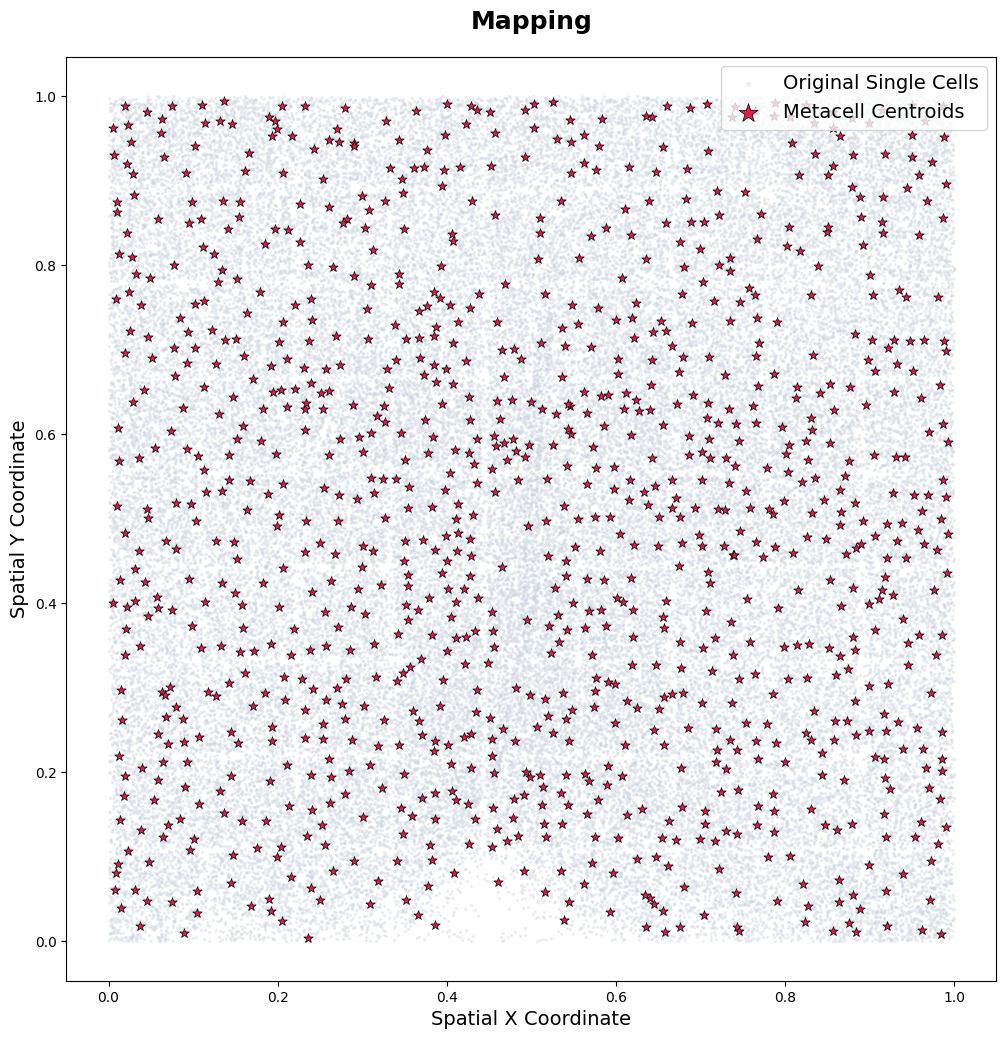

In [12]:
# stage 9 - visualization
# Plotting the original tissue cells vs. metacell centroids

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

SAVE_DIR = "/kaggle/working"
print("--- Stage 9: Visualization ---")

# =============================================================================
# 1. Load Data
# =============================================================================
# Load original spatial coordinates
data_path = os.path.join(SAVE_DIR, "stage4_tensors.pt")
data = torch.load(data_path, weights_only=True)

adata = sc.read_h5ad(os.path.join(SAVE_DIR,"stage1.h5ad"))


coords = adata.obsm['spatial']

# Load the aggregated metacell centroids from Stage 8
S_bar = np.load(os.path.join(SAVE_DIR, "stage8_S_bar.npy"))

# Clean out any empty centroids (size 0) that were dropped in Stage 8
S_bar = S_bar[np.any(S_bar != 0, axis=1)]

print(f"Loaded {coords.shape[0]:,} single cells.")
print(f"Loaded {S_bar.shape[0]:,} metacell centroids.")

# =============================================================================
# 2. Generate the Plot
# =============================================================================
plt.figure(figsize=(12, 12))

# Plot the original cells as a "ghost" background
# s=2 makes them tiny, alpha=0.3 makes them semi-transparent
plt.scatter(coords[:, 0], coords[:, 1], 
            c='#cbd5e1', s=2, alpha=0.3, label='Original Single Cells')

# Plot the Metacell centroids in the foreground
# s=50 makes them prominent, edgecolor adds a crisp border
plt.scatter(S_bar[:, 0], S_bar[:, 1], 
            c='#e11d48', s=50, marker='*', edgecolor='black', linewidth=0.5, 
            label='Metacell Centroids')

# =============================================================================
# 3. Formatting & Saving
# =============================================================================
plt.title("Mapping", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Spatial X Coordinate", fontsize=14)
plt.ylabel("Spatial Y Coordinate", fontsize=14)
plt.legend(fontsize=14, loc="upper right", markerscale=2)

# CRITICAL: Keep physical tissue aspect ratio intact
plt.axis('equal') 
plt.grid(False)

# Remove background for a cleaner, academic look
plt.gca().set_facecolor('white')

# Save to disk at 300 DPI (Publication Quality)
plot_path = os.path.join(SAVE_DIR, "stage9_tissue_map.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n[SUCCESS] Saved high-resolution tissue map to: {plot_path}")

plt.show() 